# Trefoil: Feedforward vs No-Feedforward

- **Top row**: x, y, z, yaw (actual vs reference) — **with feedforward** (`u = π(x) − π(x_ff) + u_ff`)
- **Bottom row**: same — **without feedforward** (`u = π(x) − π(x_ff)`)
- **RMSE**: position RMSE = √((x−x_ref)² + (y−y_ref)² + (z−z_ref)²)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# ===== CONFIG =====
LOG_DIR = Path('log_files/contraction_controller_px4')

FILE_1 = 'sim_contraction_trefoil_ff.csv'   # with feedforward
FILE_2 = 'sim_contraction_trefoil_no_ff.csv'   # without feedforward
# ===================

print('Available log files:')
for f in sorted(LOG_DIR.glob('*.csv')):
    print(f'  {f.name}')

Available log files:
  sim_contraction_fig8_heading_ff.csv
  sim_contraction_fig8_heading_no_ff.csv
  sim_contraction_figure_eight_ff.csv
  sim_contraction_figure_eight_no_ff.csv
  sim_contraction_spiral_ff.csv
  sim_contraction_spiral_no_ff.csv
  sim_contraction_trefoil_ff.csv
  sim_contraction_trefoil_no_ff.csv


In [3]:
def load_log(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['z']     = -df['z']
    df['z_ref'] = -df['z_ref']
    return df

def get_meta(df, col, default='unknown'):
    return df[col].dropna().iloc[0] if col in df.columns and df[col].notna().any() else default

def make_label(df, fname):
    traj = get_meta(df, 'trajectory')
    ff   = get_meta(df, 'feedforward', default=None)
    if ff is not None:
        ff_str = 'ff' if int(ff) == 1 else 'no_ff'
    else:
        ff_str = 'ff'
    return f"{fname}  [{traj} | {ff_str}]"

df1 = load_log(LOG_DIR / FILE_1)
df2 = load_log(LOG_DIR / FILE_2)

label1 = make_label(df1, FILE_1)
label2 = make_label(df2, FILE_2)

for label, df, lbl in [('File 1', df1, label1), ('File 2', df2, label2)]:
    dur = df['time'].iloc[-1] - df['time'].iloc[0]
    print(f"{label}: {lbl}  |  {len(df)} samples  |  {dur:.1f}s")

File 1: sim_contraction_trefoil_ff.csv  [trefoil | ff]  |  300 samples  |  29.9s
File 2: sim_contraction_trefoil_no_ff.csv  [trefoil | no_ff]  |  300 samples  |  29.9s


## Position & Yaw: Actual vs Reference

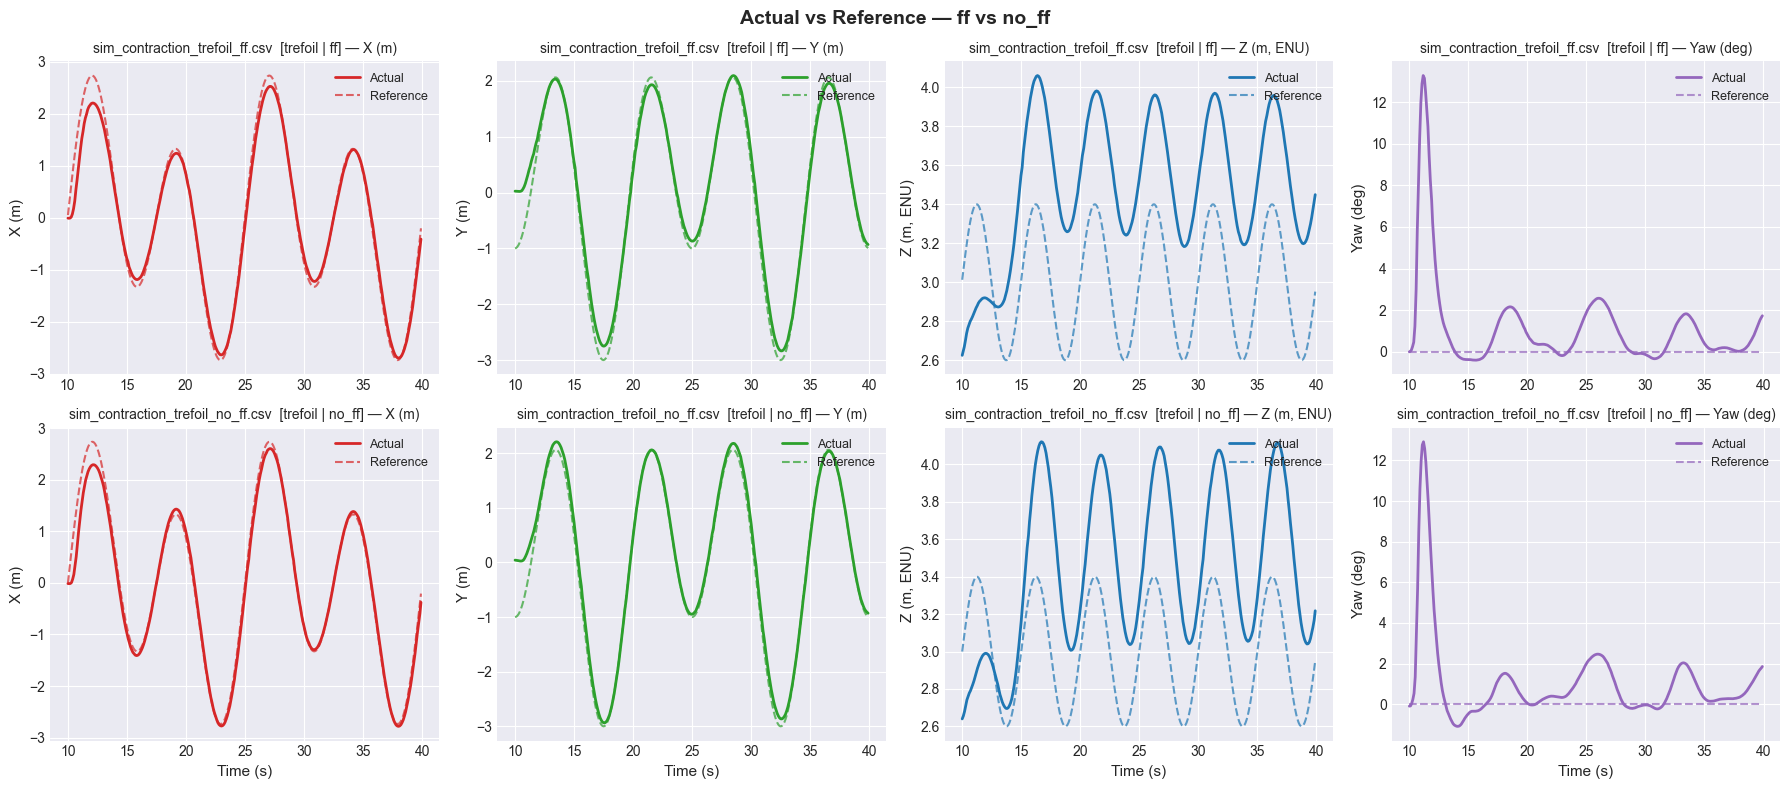

In [4]:
def plot_row(axes, df, row_label):
    coords = [
        ('x',   'x_ref',   'X (m)',       'tab:red'),
        ('y',   'y_ref',   'Y (m)',       'tab:green'),
        ('z',   'z_ref',   'Z (m, ENU)',  'tab:blue'),
        ('yaw', 'yaw_ref', 'Yaw (deg)',   'tab:purple'),
    ]
    for ax, (actual, ref, ylabel, color) in zip(axes, coords):
        if actual == 'yaw':
            a_data = np.rad2deg(df[actual])
            r_data = np.rad2deg(df[ref])
        else:
            a_data = df[actual]
            r_data = df[ref]
        ax.plot(df['time'], a_data, color=color, lw=2.0, label='Actual')
        ax.plot(df['time'], r_data, color=color, lw=1.5, ls='--', alpha=0.7, label='Reference')
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.set_title(f"{row_label} — {ylabel}", fontsize=10)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='row')
plot_row(axes[0], df1, label1)
plot_row(axes[1], df2, label2)
for ax in axes[1]:
    ax.set_xlabel('Time (s)', fontsize=11)
fig.suptitle('Actual vs Reference — ff vs no_ff', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## RMSE Comparison

Position RMSE = √( (x − x_ref)² + (y − y_ref)² + (z − z_ref)² )

In [5]:
def position_rmse(df):
    err_sq = (df['x']-df['x_ref'])**2 + (df['y']-df['y_ref'])**2 + (df['z']-df['z_ref'])**2
    return float(np.sqrt(err_sq.mean()))

def per_axis_rmse(df):
    return {
        'x':   float(np.sqrt(((df['x']   - df['x_ref']  )**2).mean())),
        'y':   float(np.sqrt(((df['y']   - df['y_ref']  )**2).mean())),
        'z':   float(np.sqrt(((df['z']   - df['z_ref']  )**2).mean())),
        'yaw': float(np.sqrt(((df['yaw'] - df['yaw_ref'])**2).mean())),
    }

rmse1 = position_rmse(df1)
rmse2 = position_rmse(df2)
ax1   = per_axis_rmse(df1)
ax2   = per_axis_rmse(df2)

w = 32
print(f"{'Metric':<28} {label1[:w]:>{w}} {label2[:w]:>{w}}")
print('-' * (28 + 2*w + 2))
print(f"{'Position RMSE (m)':<28} {rmse1:{w}.4f} {rmse2:{w}.4f}")
print(f"{'  RMSE x (m)':<28} {ax1['x']:{w}.4f} {ax2['x']:{w}.4f}")
print(f"{'  RMSE y (m)':<28} {ax1['y']:{w}.4f} {ax2['y']:{w}.4f}")
print(f"{'  RMSE z (m)':<28} {ax1['z']:{w}.4f} {ax2['z']:{w}.4f}")
print(f"{'  RMSE yaw (rad)':<28} {ax1['yaw']:{w}.4f} {ax2['yaw']:{w}.4f}")

Metric                       sim_contraction_trefoil_ff.csv   sim_contraction_trefoil_no_ff.cs
----------------------------------------------------------------------------------------------
Position RMSE (m)                                      0.6508                           0.6299
  RMSE x (m)                                           0.2172                           0.1958
  RMSE y (m)                                           0.2235                           0.2043
  RMSE z (m)                                           0.5713                           0.5628
  RMSE yaw (rad)                                       0.0444                           0.0424


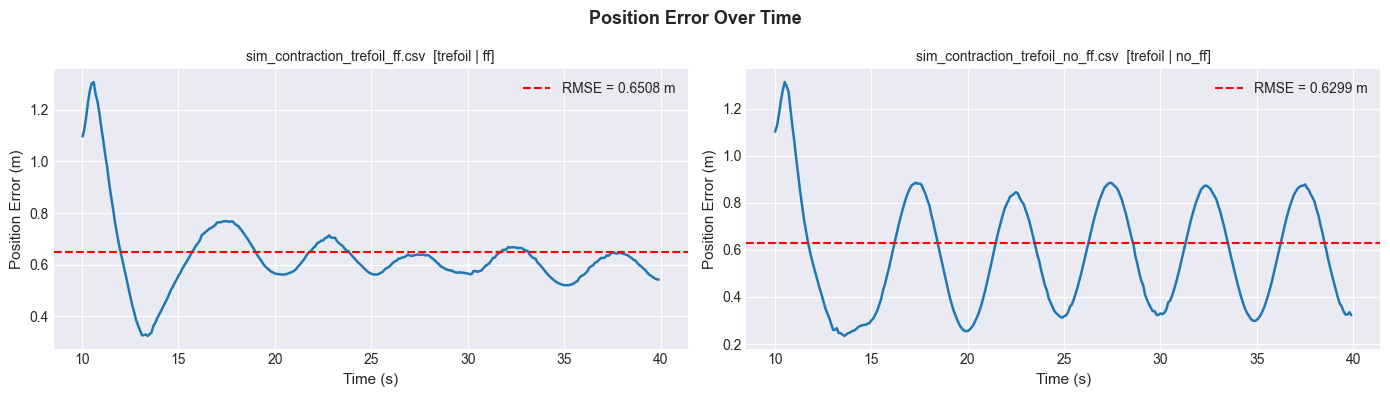

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, lbl, rmse in [(axes[0], df1, label1, rmse1), (axes[1], df2, label2, rmse2)]:
    err = np.sqrt((df['x']-df['x_ref'])**2 + (df['y']-df['y_ref'])**2 + (df['z']-df['z_ref'])**2)
    ax.plot(df['time'], err, lw=1.8)
    ax.axhline(rmse, color='red', ls='--', lw=1.5, label=f'RMSE = {rmse:.4f} m')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Position Error (m)', fontsize=11)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=10)
fig.suptitle('Position Error Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

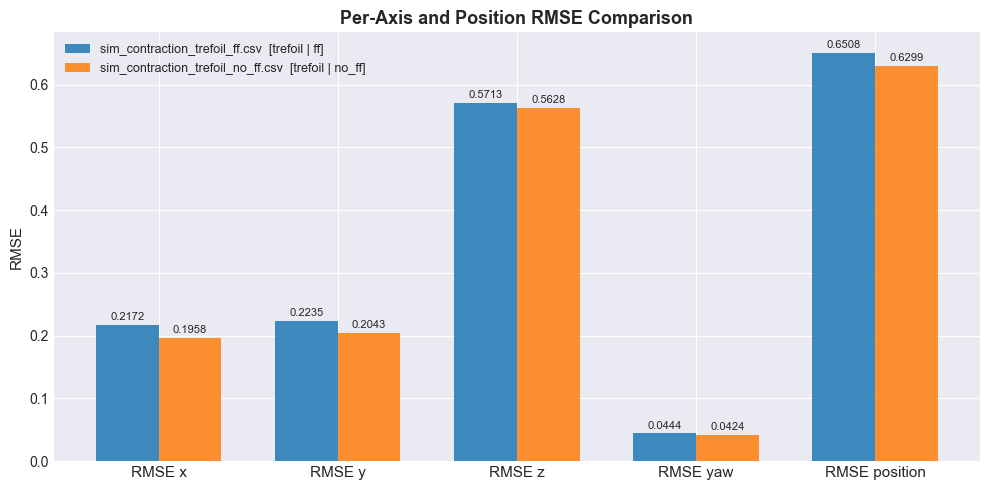

In [7]:
metrics = ['x', 'y', 'z', 'yaw', 'position']
vals1   = [ax1['x'], ax1['y'], ax1['z'], ax1['yaw'], rmse1]
vals2   = [ax2['x'], ax2['y'], ax2['z'], ax2['yaw'], rmse2]
x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, vals1, w, label=label1, alpha=0.85)
bars2 = ax.bar(x + w/2, vals2, w, label=label2, alpha=0.85)
ax.bar_label(bars1, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels([f'RMSE {m}' for m in metrics], fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Per-Axis and Position RMSE Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()